In [3]:
import pandas as pd
import numpy as np


In [11]:
df = pd .read_csv("Churn_Modelling.csv")
df.shape

(10000, 14)

In [5]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [140]:
df.info

<bound method DataFrame.info of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfP

In [169]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Exited'].value_counts()


Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [12]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [174]:
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

In [14]:
# One HOt Encoding
X = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True
)

In [177]:
print(X.columns)

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='str')


In [15]:


# training
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
     X,
     y,
     test_size=0.2,
     random_state=1
 )

In [179]:
X_train.shape

(8000, 11)

In [16]:
#scalling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test) 

In [181]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [17]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [18]:
print(X_train_scaled.shape)

(8000, 11)


In [19]:
model = Sequential()
model.add(Dense(3,activation="relu",input_dim = 11))
model.add(Dense(1,activation="sigmoid"))

e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [193]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# model compile
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [21]:
# fiting model 
History = model.fit(X_train_scaled,y_train,epochs=10,validation_split=0.2)


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7423 - loss: 0.5896 - val_accuracy: 0.7812 - val_loss: 0.5429
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7852 - loss: 0.5250 - val_accuracy: 0.7937 - val_loss: 0.5063
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - loss: 0.4908 - val_accuracy: 0.7987 - val_loss: 0.4859
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8048 - loss: 0.4700 - val_accuracy: 0.7981 - val_loss: 0.4745
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8092 - loss: 0.4573 - val_accuracy: 0.8025 - val_loss: 0.4676
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8116 - loss: 0.4492 - val_accuracy: 0.8044 - val_loss: 0.4619
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8130 - loss: 0.4438 - val_accuracy: 0.8044 - val_loss: 0.4584
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8145 - loss: 0.4398 - val_accuracy: 0.

In [23]:
model.layers[0].get_weights()

[array([[-4.14478689e-01, -2.68661171e-01,  1.52972803e-01],
        [ 5.05790673e-02,  7.76431262e-01, -5.59888840e-01],
        [-2.65723884e-01,  4.89700884e-02,  3.20066422e-01],
        [-4.19681579e-01, -1.96679652e-01, -2.54267573e-01],
        [ 1.51180491e-01,  7.16292784e-02, -2.13282667e-02],
        [-1.52110800e-01, -2.07755268e-01,  9.60277976e-06],
        [-2.07851052e-01, -8.57419908e-01,  3.40848267e-01],
        [ 3.60852659e-01,  1.78453550e-01, -2.03687876e-01],
        [-6.21869683e-01, -6.16430864e-02, -7.16975331e-02],
        [-7.34578967e-01, -8.09169188e-02,  4.11949396e-01],
        [-4.18243676e-01, -1.11837626e-01,  6.41248703e-01]], dtype=float32),
 array([ 0.52242583, -0.16076824,  0.70775235], dtype=float32)]

In [24]:
model.layers[1].get_weights()

[array([[-0.6020495 ],
        [ 0.90460217],
        [-0.9311899 ]], dtype=float32),
 array([-0.67925763], dtype=float32)]

In [25]:
y_log=model.predict(X_test_scaled)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [26]:
y_pred = np.where(y_log>0.5,1,0)

In [27]:
# accuracy score

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.816


In [28]:
import matplotlib.pyplot as plt

In [29]:
History.history

{'accuracy': [0.7423437237739563,
  0.78515625,
  0.7984374761581421,
  0.8048437237739563,
  0.8092187643051147,
  0.8115624785423279,
  0.8129687309265137,
  0.8145312666893005,
  0.8145312666893005,
  0.8170312643051147],
 'loss': [0.5896363258361816,
  0.5249630212783813,
  0.49078992009162903,
  0.47003382444381714,
  0.45731449127197266,
  0.44915249943733215,
  0.44382479786872864,
  0.43978434801101685,
  0.43656283617019653,
  0.4339124262332916],
 'val_accuracy': [0.78125,
  0.793749988079071,
  0.7987499833106995,
  0.7981250286102295,
  0.8025000095367432,
  0.8043749928474426,
  0.8043749928474426,
  0.8043749928474426,
  0.8050000071525574,
  0.8068749904632568],
 'val_loss': [0.5429434180259705,
  0.5062553882598877,
  0.4858990013599396,
  0.4745057225227356,
  0.46756526827812195,
  0.4618730843067169,
  0.4584245979785919,
  0.4545450508594513,
  0.45142504572868347,
  0.4489310085773468]}

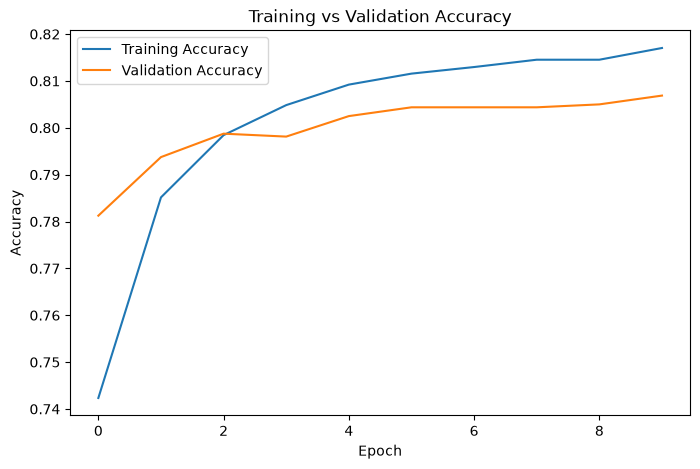

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(History.history["accuracy"], label="Training Accuracy")
plt.plot(History.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig("images/accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

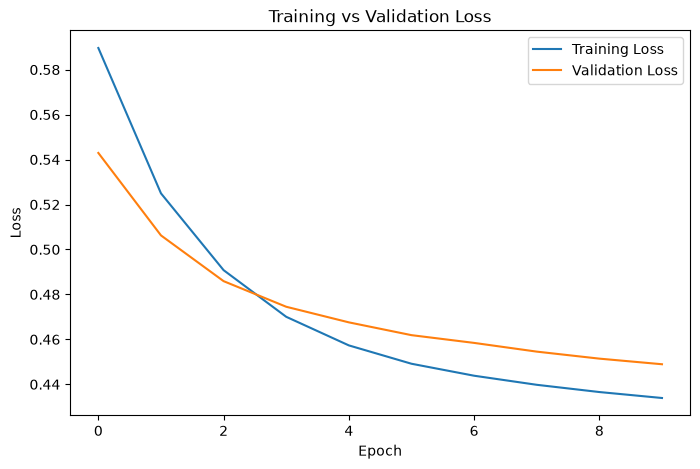

In [31]:
plt.figure(figsize=(8,5))

plt.plot(History.history["loss"], label="Training Loss")
plt.plot(History.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig("images/loss.png", dpi=300, bbox_inches="tight")

plt.show()

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


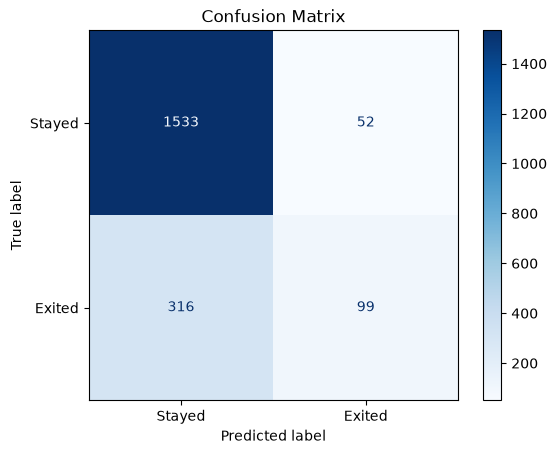

In [33]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Exited"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
from sklearn.metrics import roc_curve, auc

In [35]:
# ROC Curve ke liye probability chahiye.

y_prob = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [36]:
# Calculate ROC

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

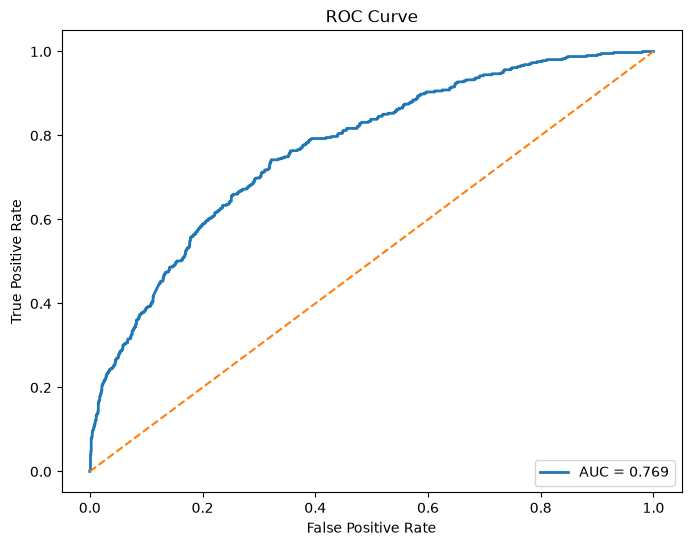

In [37]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.savefig(
    "images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

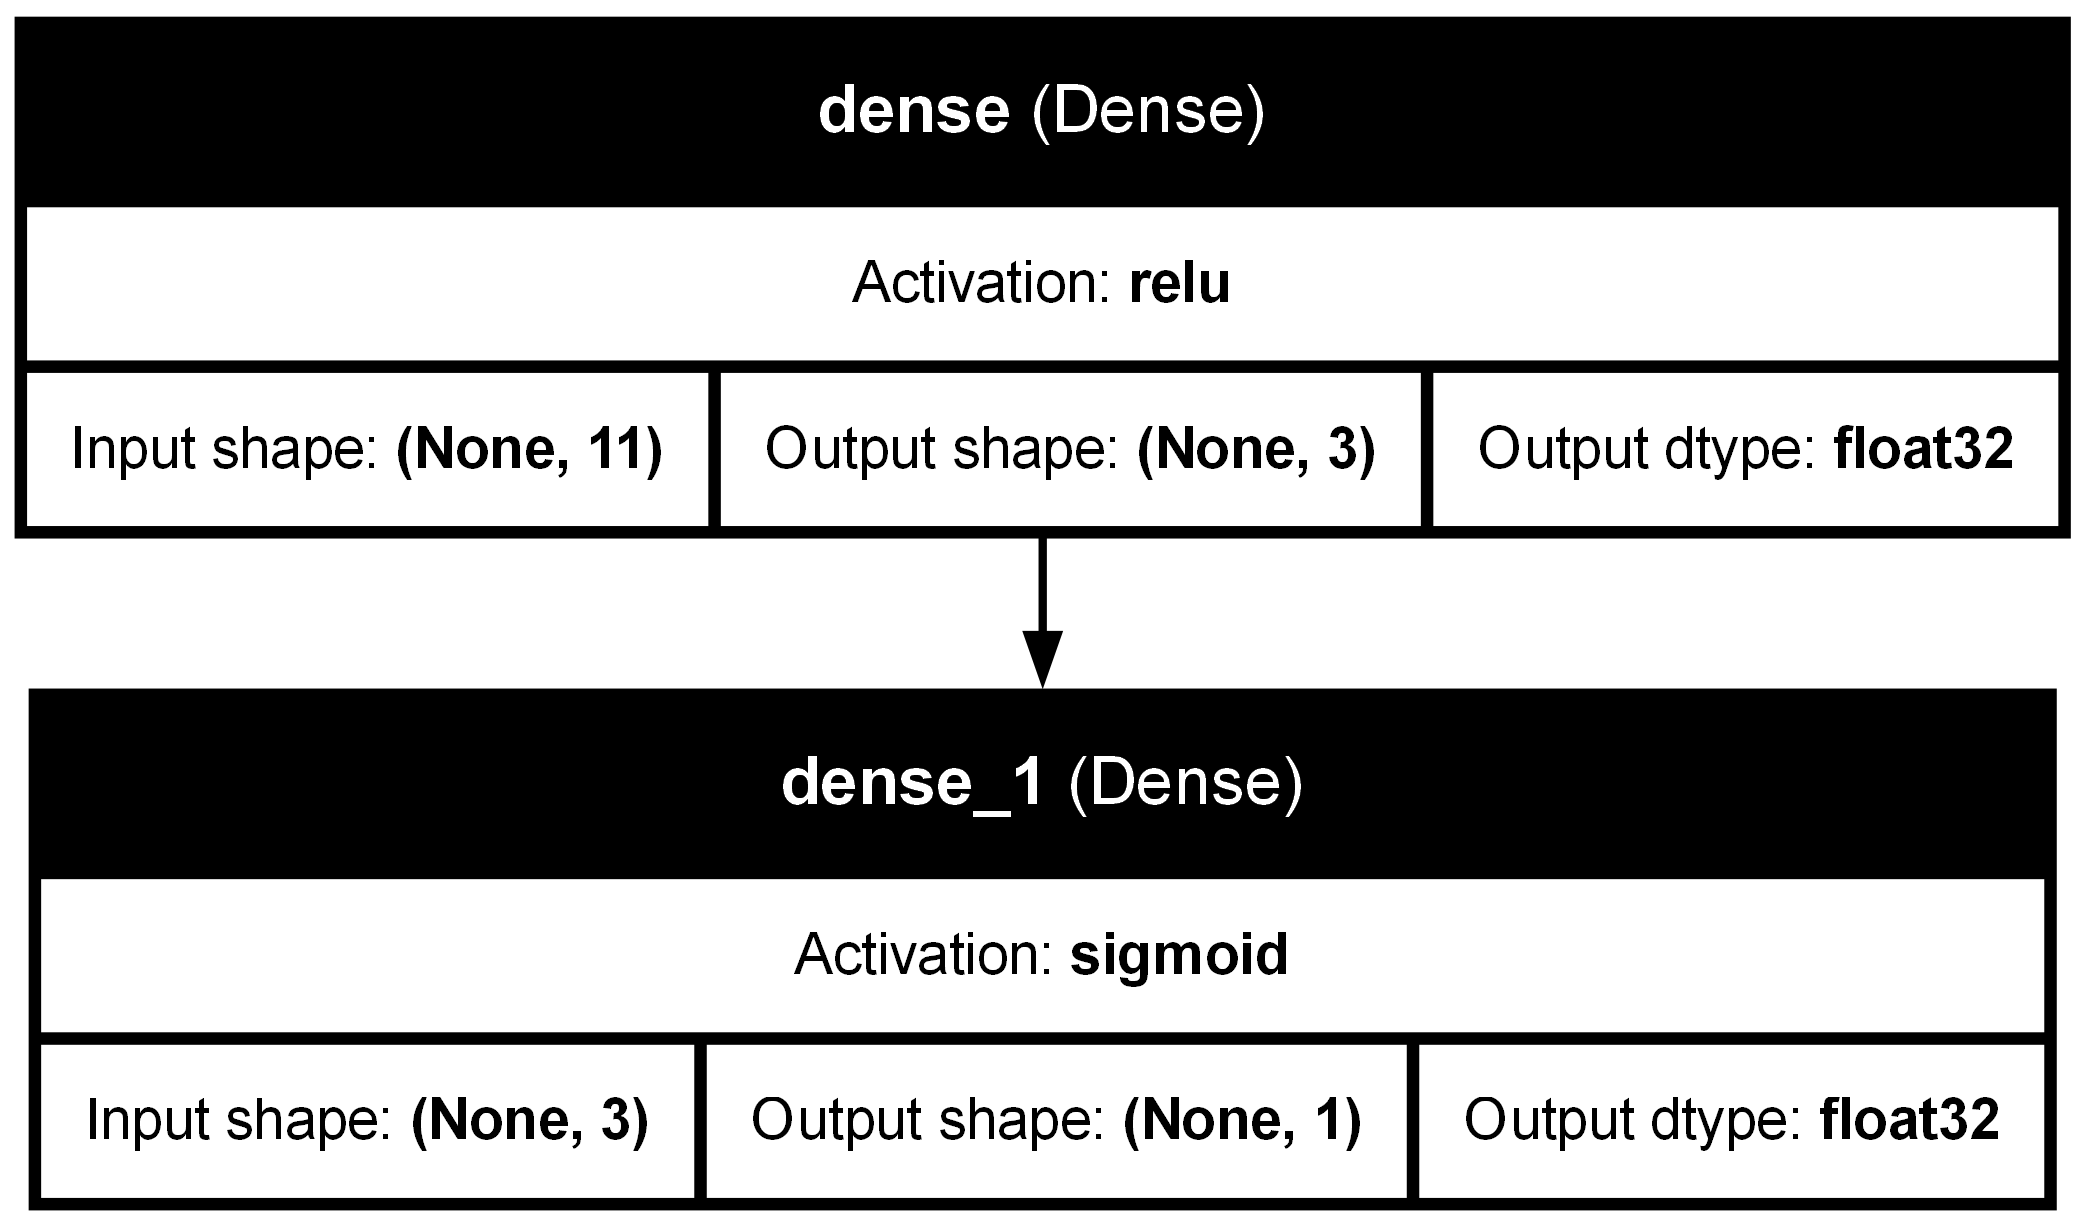

In [38]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="images/model_architecture.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    show_layer_activations=True,
    dpi=300
)

In [39]:
import joblib

joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']